# Práctica completa de Matplotlib

Análisis del archivo `nacimientos_defunciones.csv`.

Este notebook carga el CSV, limpia los datos, crea gráficos y muestra un resumen final.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("nacimientos_defunciones.csv")
df.head()

df.isna().sum()

Año            0
Nacimientos    0
Defunciones    0
dtype: int64

## 2. Revisar la estructura del archivo

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Año          72 non-null     int64
 1   Nacimientos  72 non-null     int64
 2   Defunciones  72 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.8 KB


In [5]:
df.columns

Index(['Año', 'Nacimientos', 'Defunciones'], dtype='str')

## 3. Limpiar nombres de columnas

Se eliminan espacios y se pasan los nombres a minúscula para trabajar más fácil.

In [6]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)
df.head()

Index(['año', 'nacimientos', 'defunciones'], dtype='str')


,año,nacimientos,defunciones
0,1950,37248,9769
1,1951,39239,9631
2,1952,42461,9902
3,1953,42817,10312
4,1954,48157,9713


## 4. Detectar columnas principales

Este bloque intenta encontrar automáticamente las columnas de año, nacimientos y defunciones.

In [7]:
def buscar_columna(posibles_nombres):
    for columna in df.columns:
        nombre = columna.lower().strip()
        for posible in posibles_nombres:
            if posible in nombre:
                return columna
    return None

col_anio = buscar_columna(["año", "ano", "year"])
col_nacimientos = buscar_columna(["nacimiento", "nacimientos", "birth"])
col_defunciones = buscar_columna(["defuncion", "defunción", "defunciones", "muerte", "death"])

print("Columna año:", col_anio)
print("Columna nacimientos:", col_nacimientos)
print("Columna defunciones:", col_defunciones)

Columna año: año
Columna nacimientos: nacimientos
Columna defunciones: defunciones


Si alguna columna aparece como `None`, escribe manualmente el nombre correcto según lo que te salió en `df.columns`.

In [8]:
# Si alguna columna no se detecta, puedes cambiarla aquí manualmente:
# col_anio = "año"
# col_nacimientos = "nacimientos"
# col_defunciones = "defunciones"

## 5. Limpieza de datos numéricos

In [9]:
df[col_anio] = pd.to_numeric(df[col_anio], errors="coerce")
df[col_nacimientos] = pd.to_numeric(df[col_nacimientos], errors="coerce")
df[col_defunciones] = pd.to_numeric(df[col_defunciones], errors="coerce")

df = df.dropna(subset=[col_anio, col_nacimientos, col_defunciones])

df[col_anio] = df[col_anio].astype(int)
df = df.sort_values(by=col_anio)

df.head()

,año,nacimientos,defunciones
0,1950,37248,9769.0
1,1951,39239,9631.0
2,1952,42461,9902.0
3,1953,42817,10312.0
4,1954,48157,9713.0


## 6. Gráfico de líneas: nacimientos y defunciones por año

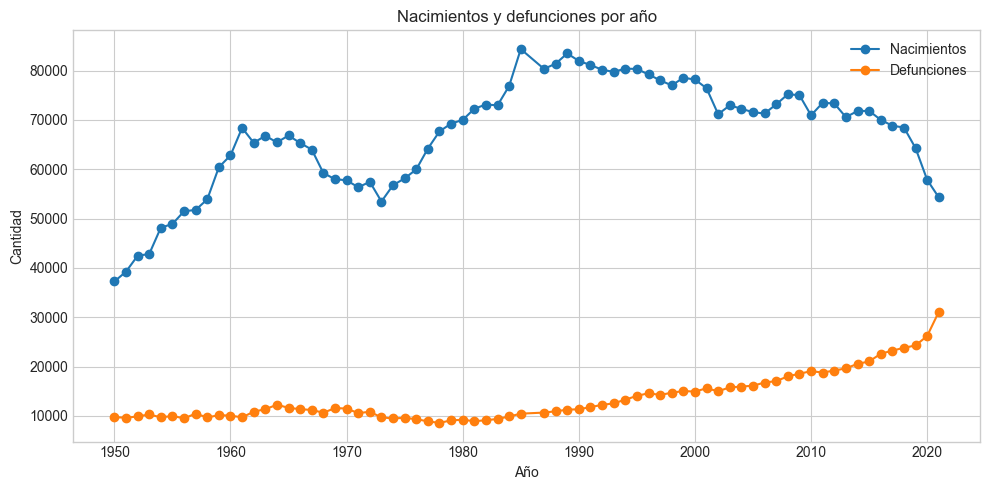

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(df[col_anio], df[col_nacimientos], marker="o", label="Nacimientos")
plt.plot(df[col_anio], df[col_defunciones], marker="o", label="Defunciones")

plt.title("Nacimientos y defunciones por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Gráfico de barras comparativo

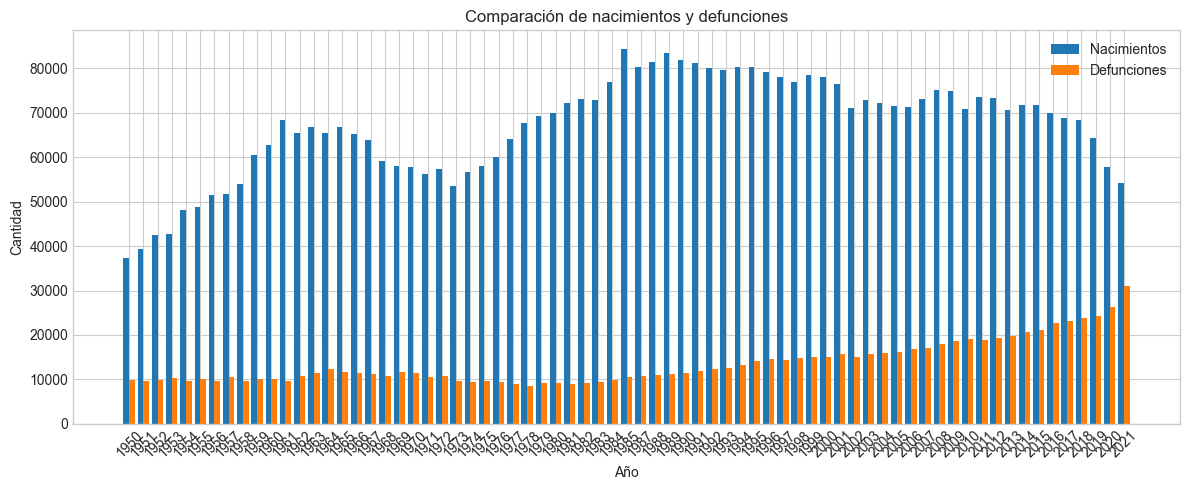

In [11]:
plt.figure(figsize=(12, 5))

ancho = 0.4
x = range(len(df))

plt.bar([i - ancho/2 for i in x], df[col_nacimientos], width=ancho, label="Nacimientos")
plt.bar([i + ancho/2 for i in x], df[col_defunciones], width=ancho, label="Defunciones")

plt.title("Comparación de nacimientos y defunciones")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.xticks(x, df[col_anio], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Crear columna de crecimiento natural

Crecimiento natural = nacimientos - defunciones.

In [12]:
df["crecimiento_natural"] = df[col_nacimientos] - df[col_defunciones]
df.head()

,año,nacimientos,defunciones,crecimiento_natural
0,1950,37248,9769.0,27479.0
1,1951,39239,9631.0,29608.0
2,1952,42461,9902.0,32559.0
3,1953,42817,10312.0,32505.0
4,1954,48157,9713.0,38444.0


## 9. Gráfico del crecimiento natural

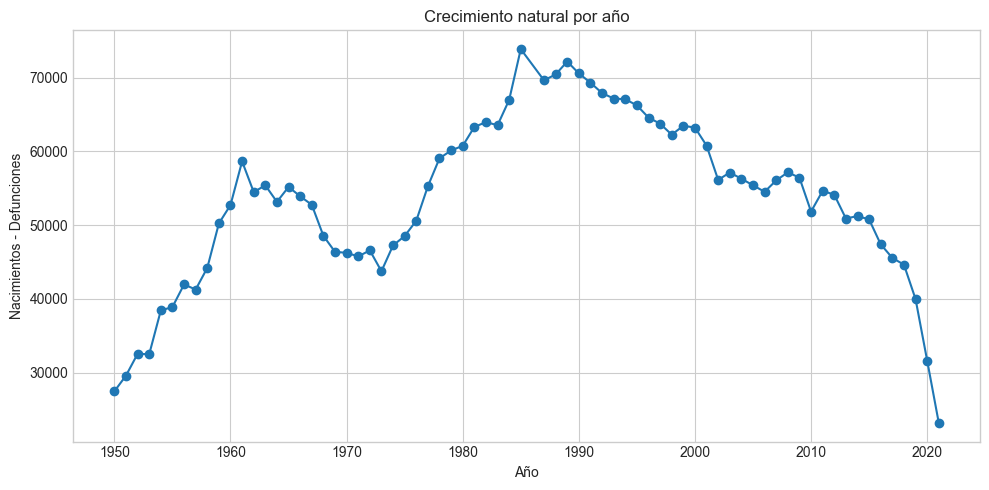

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(df[col_anio], df["crecimiento_natural"], marker="o")

plt.title("Crecimiento natural por año")
plt.xlabel("Año")
plt.ylabel("Nacimientos - Defunciones")
plt.tight_layout()
plt.show()

## 10. Año con más nacimientos

In [14]:
fila_max_nac = df.loc[df[col_nacimientos].idxmax()]

print("Año con más nacimientos:", int(fila_max_nac[col_anio]))
print("Cantidad de nacimientos:", int(fila_max_nac[col_nacimientos]))

Año con más nacimientos: 1985
Cantidad de nacimientos: 84337


## 11. Año con más defunciones

In [15]:
fila_max_def = df.loc[df[col_defunciones].idxmax()]

print("Año con más defunciones:", int(fila_max_def[col_anio]))
print("Cantidad de defunciones:", int(fila_max_def[col_defunciones]))

Año con más defunciones: 2021
Cantidad de defunciones: 31093


## 12. Resumen final

In [16]:
print("Resumen del análisis")
print("--------------------")
print("Total de registros:", len(df))
print("Año inicial:", df[col_anio].min())
print("Año final:", df[col_anio].max())
print("Total de nacimientos:", int(df[col_nacimientos].sum()))
print("Total de defunciones:", int(df[col_defunciones].sum()))
print("Crecimiento natural total:", int(df["crecimiento_natural"].sum()))

Resumen del análisis
--------------------
Total de registros: 71
Año inicial: 1950
Año final: 2021
Total de nacimientos: 4763013
Total de defunciones: 965052
Crecimiento natural total: 3797961


## 13. Conclusión

In [17]:
print("Conclusión:")
print("El análisis permite comparar la cantidad de nacimientos y defunciones a través de los años.")
print("También permite observar el crecimiento natural, calculado como nacimientos menos defunciones.")
print("Las gráficas ayudan a identificar los años con mayores cambios en la población.")

Conclusión:
El análisis permite comparar la cantidad de nacimientos y defunciones a través de los años.
También permite observar el crecimiento natural, calculado como nacimientos menos defunciones.
Las gráficas ayudan a identificar los años con mayores cambios en la población.
